# Expense Classification: End-to-End AI/ML/NLP Pipeline
### Data Exploration, EDA, and NLP-Based Text Classification
---
**Objective:** Predict the expense type (`Services`, `Equipment`, or `Material`)  
from free-text `Remarks`.

## Environment Setup

In [27]:
pip install -q pandas numpy matplotlib seaborn scikit-learn openpyxl python-dotenv

Note: you may need to restart the kernel to use updated packages.


In [2]:

import warnings, re
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, f1_score, balanced_accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.utils.class_weight import compute_class_weight

%matplotlib inline
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
print("✅ All libraries loaded successfully")

✅ All libraries loaded successfully


## Data Loading

In [4]:
try:
    df_raw = pd.read_excel('./content/data.xlsx')
    print("'data.xls' loaded successfully!")
    display(df_raw.head(10))
except FileNotFoundError:
    print("Error: 'data.xls' not found. Please upload it to your Colab environment.")
except Exception as e:
    print(f"An error occurred while loading 'data.xls': {e}")

'data.xls' loaded successfully!


,Year,Debit,Credit,Net,Remarks
0,FY23,30000.0,0,30000.0,"Services Professional Services , Consultancy A..."
1,FY23,270000.0,0,270000.0,"Services Professional Services , Consultancy A..."
2,FY23,250000.0,0,250000.0,Exp reclass entry in N2 (Godrej)
3,FY23,14500.0,0,14500.0,Dispenser Water - Frosty plus - (Make - Atlantis)
4,FY23,59400.0,0,59400.0,"Almirah - Office use , Steel Almirah with four..."
5,FY23,59400.0,0,59400.0,"701257471208 Almirah - Office use , Steel Almi..."
6,FY23,12400.0,0,12400.0,Dispenser Water - Frosty plus - (Make - Atlantis)
7,FY23,12735479.0,0,12735479.0,Space matrix Cost T/f from project Upgradation...
8,FY23,315000.0,0,315000.0,Provision reclass of Godrej May22
9,FY23,30200.0,0,30200.0,1.5 Tr. Split AC - 2 Star - Non Inverter ( Dai...


In [5]:
print("── Column dtypes ──")
print(df_raw.dtypes)
print()
print("── Null counts ──")
print(df_raw.isnull().sum())

── Column dtypes ──
Year           str
Debit      float64
Credit       int64
Net        float64
Remarks        str
dtype: object

── Null counts ──
Year       0
Debit      0
Credit     0
Net        0
Remarks    1
dtype: int64


## Data Cleaning & Label Engineering

### Justification
The dataset has **no explicit label column**. Labels must be **inferred from the
`Remarks` free-text field** itself:

| Keyword signal | Assigned label |
|---|---|
| Starts with / contains `Services` | `Services` |
| Physical items (AC, Almirah, Dispenser, Camera, …) | `Equipment` |
| Raw materials (pipe, wire, insulation, copper, …) | `Material` |

**Additional cleaning steps:**
1. Strip leading/trailing whitespace.
2. Remove numeric-only tokens and special characters that carry no semantic meaning.
3. Drop rows where `Remarks` is NaN or empty.
4. Embedding-Based Clustering (Unsupervised)


> Here couple of options for trade-off along with Standardise casing for rule-based labelling only as
>
> Option - Embedding-based clustering as use of sentence embeddings + KMeans/UMAP to discover natural clusters, then manually name them as part of tradditional Standardise KV as rule-based.
>
> Option - LLM-Based Zero-Shot Labelling , which will be best fit for production ready code as when the ground truth is abesent and budget allows.
Use LLM Model to label all 267 rows once as a data preparation step, then treat those as ground-truth labels for training.
>
> **Use zero-shot classification**.
>
> Refer to [Alternate option](#alternate-option) as with lighter model.


In [ ]:
# Install sentence-transformers library
%pip install sentence-transformers
print("✅ sentence-transformers installed successfully!")

In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sentence_transformers import SentenceTransformer

df = df_raw.copy()

# Drop rows where 'Remarks' is NaN before processing
df.dropna(subset=['Remarks'], inplace=True)

# Ensure 'Remarks' column is of string type
df['Remarks'] = df['Remarks'].astype(str)

model = SentenceTransformer('all-MiniLM-L6-v2')  # 80MB, runs locally
embeddings = model.encode(df['Remarks'].tolist(), show_progress_bar=True)
embeddings_norm = normalize(embeddings)

# Cluster into 3 groups
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(embeddings_norm)

# Inspect cluster samples to manually assign label names
for cluster_id in range(3):
    print(f"\n── Cluster {cluster_id} samples ──")
    samples = df[df['Cluster'] == cluster_id]['Remarks'].sample(5, random_state=42).tolist()
    for s in samples:
        print(f"  {s[:80]}")

# After inspection, manually map cluster → label
CLUSTER_MAP = {0: 'Services', 1: 'Equipment', 2: 'Material'}  # adjust after inspection
df['Label'] = df['Cluster'].map(CLUSTER_MAP)

Batches: 100%|██████████| 9/9 [00:08<00:00,  1.06it/s]



── Cluster 0 samples ──
  301536364959 Supply of 3 POS  Machine(moveable item)
  Dispenser Water - Frosty plus - (Make - Atlantis)
  SUPPLY OF  Wheel Chair, Wheel Chair Folding Type Dim : 42" L x 22" W x 36" H wit
  REIMBURESMENT OF  Freight & Cartridge of purchase of chair for food court
  Eye Wash Portable Unit (EWP 07), Make - Euronics/equivalent, Size - 540mm*255mm*

── Cluster 1 samples ──
  SITC - 3 Core Cable 1.5 Sqmm (Polycab/Anchor)
  Hard Drive Surveillance -Capacity -  4 TB, Make - Seagate
  Ahuja - CSD 6303T (30 Watts)
  SITC Cisco 8 Port Managed PoE Switch
  SITC of Customized Dynamic Dashboard development charges which will be compatibl

── Cluster 2 samples ──
  Services Professional Services , Consultancy Architects Services Design at Ameni
  Services Fire Fighting- FAS System-Supply installation testing and commissioning
  Tester LAN Cable- -Line Tester-D-Link
  WC  03/07/2022 Supplying, fixing, testing and commissioning of chilled water pip
  Consultancy Testing & Co

In [8]:
# Cleaned text feature for ML
def clean_remarks(text):
    text = str(text).strip()  # Strip leading/trailing whitespace and ensure string type
    text = re.sub(r'\b\d+\b', '', text)  # Remove numeric-only tokens
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text) # Remove special characters
    text = text.lower() # Convert to lowercase for consistency
    text = re.sub(r'\s+', ' ', text).strip() # Normalize multiple spaces to single space and strip again
    return text

df['Remarks_cleaned'] = df['Remarks'].apply(clean_remarks)

print("✅ Remarks column cleaned successfully!")
print("Original vs Cleaned Remarks samples:")
display(df[['Remarks', 'Remarks_cleaned', 'Label']].sample(5, random_state=42))

✅ Remarks column cleaned successfully!
Original vs Cleaned Remarks samples:


,Remarks,Remarks_cleaned,Label
84,SITC of ball valve with fitting accessories 1...,sitc of ball valve with fitting accessories ma...,Services
46,TV LED - 43LK 5260 - (Make - LG),tv led 43lk make lg,Equipment
184,SAFETY PO 27589 Exhaust Fan Flexible Duct for...,safety po exhaust fan flexible duct for fire s...,Services
237,GLOBAL ENGINEERING 27119 AQI monitoring,global engineering aqi monitoring,Material
178,Amenity Block Baby Diaper changing station - S...,amenity block baby diaper changing station sta...,Services


In [9]:
# Financial columns
df['Debit']  = pd.to_numeric(df['Debit'],  errors='coerce').fillna(0)
df['Credit'] = pd.to_numeric(df['Credit'], errors='coerce').fillna(0)
df['Net']    = pd.to_numeric(df['Net'],    errors='coerce').fillna(0)

print(f"\nFinal cleaned dataset shape: {df.shape}")
df[['Year','Debit','Credit','Net','Label','Remarks']].head(8)


Final cleaned dataset shape: (267, 8)


,Year,Debit,Credit,Net,Label,Remarks
0,FY23,30000.0,0,30000.0,Material,"Services Professional Services , Consultancy A..."
1,FY23,270000.0,0,270000.0,Material,"Services Professional Services , Consultancy A..."
2,FY23,250000.0,0,250000.0,Services,Exp reclass entry in N2 (Godrej)
3,FY23,14500.0,0,14500.0,Services,Dispenser Water - Frosty plus - (Make - Atlantis)
4,FY23,59400.0,0,59400.0,Services,"Almirah - Office use , Steel Almirah with four..."
5,FY23,59400.0,0,59400.0,Services,"701257471208 Almirah - Office use , Steel Almi..."
6,FY23,12400.0,0,12400.0,Services,Dispenser Water - Frosty plus - (Make - Atlantis)
7,FY23,12735479.0,0,12735479.0,Equipment,Space matrix Cost T/f from project Upgradation...


## Exploratory Data Analysis (EDA)

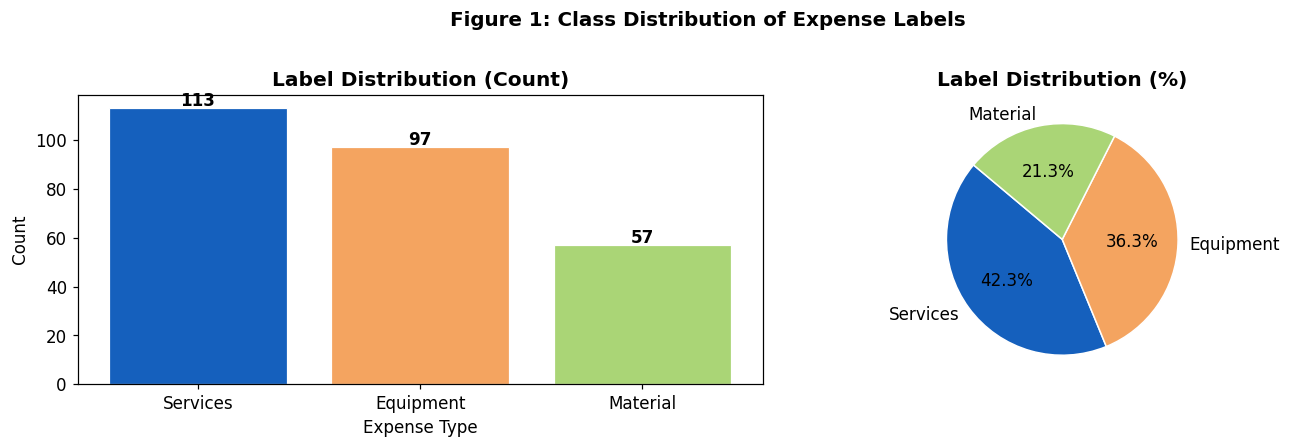

Class imbalance present — justifies macro F1 + Balanced Accuracy as metrics.


In [10]:
# Label Distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

label_counts = df['Label'].value_counts()
colors = ['#1560BD', '#F4A460', '#AAD576']

axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='white', linewidth=0.8)
axes[0].set_title('Label Distribution (Count)', fontweight='bold')
axes[0].set_xlabel('Expense Type')
axes[0].set_ylabel('Count')
for i, (idx, val) in enumerate(label_counts.items()):
    axes[0].text(i, val + 1, str(val), ha='center', fontweight='bold')

axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Label Distribution (%)', fontweight='bold')

plt.suptitle('Figure 1: Class Distribution of Expense Labels', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('fig1_label_dist.png', bbox_inches='tight')
plt.show()
print("Class imbalance present — justifies macro F1 + Balanced Accuracy as metrics.")

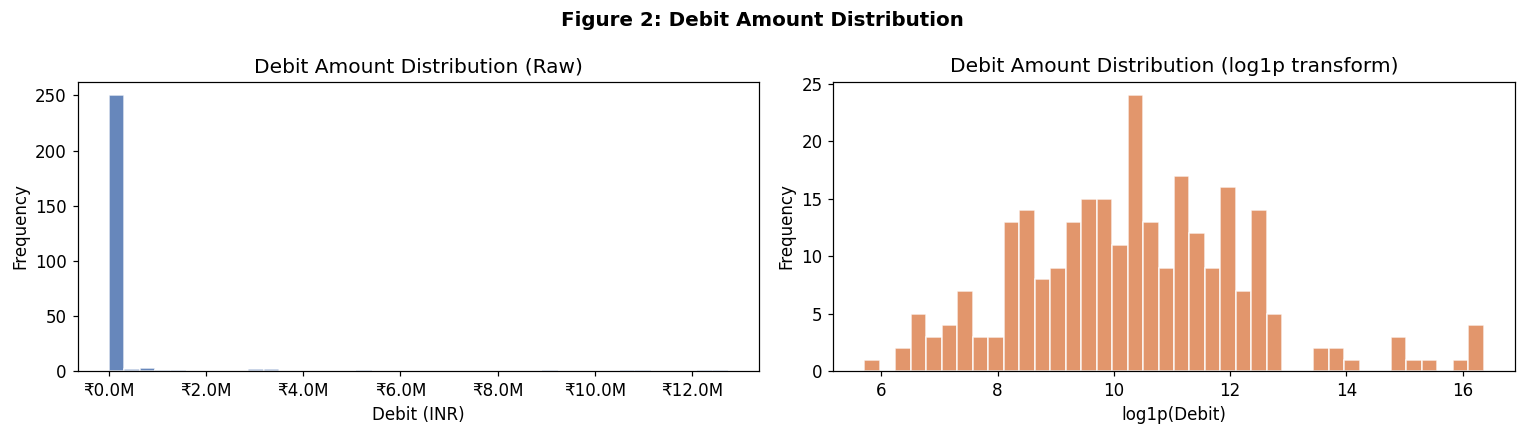

In [11]:
# Debit Amount Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df['Debit'], bins=40, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].set_title('Debit Amount Distribution (Raw)')
axes[0].set_xlabel('Debit (INR)')
axes[0].set_ylabel('Frequency')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e6:.1f}M'))

axes[1].hist(np.log1p(df['Debit']), bins=40, color='#DD8452', edgecolor='white', alpha=0.85)
axes[1].set_title('Debit Amount Distribution (log1p transform)')
axes[1].set_xlabel('log1p(Debit)')
axes[1].set_ylabel('Frequency')

plt.suptitle('Figure 2: Debit Amount Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig2_debit_dist.png', bbox_inches='tight')
plt.show()


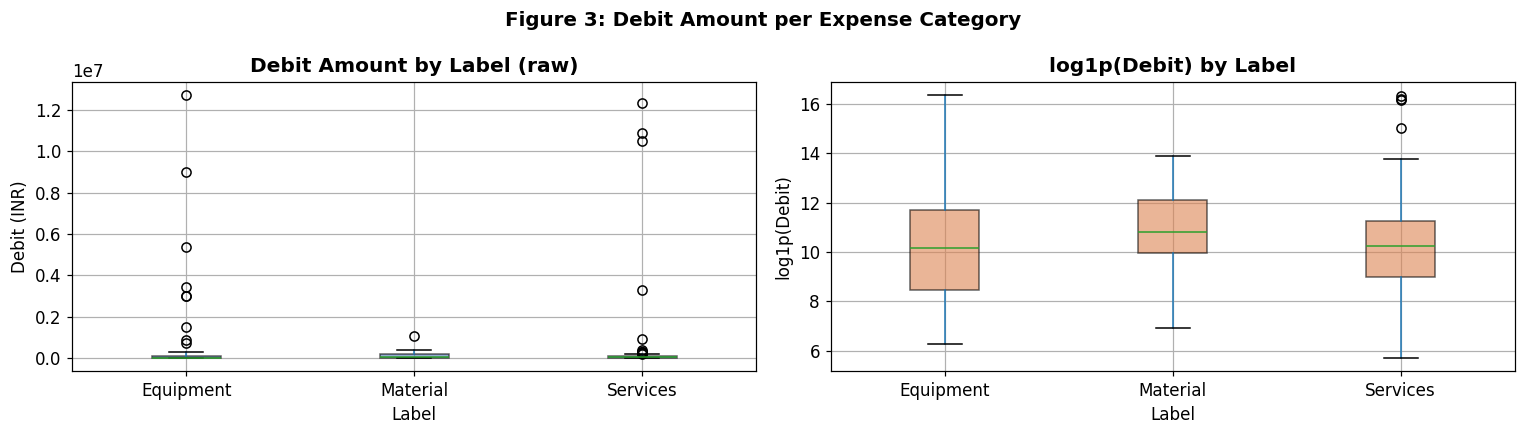

In [12]:
# Debit by Label
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.boxplot(column='Debit', by='Label', ax=axes[0], patch_artist=True,
           boxprops=dict(facecolor='#4C72B0', alpha=0.6))
axes[0].set_title('Debit Amount by Label (raw)', fontweight='bold')
axes[0].set_xlabel('Label'); axes[0].set_ylabel('Debit (INR)')
plt.sca(axes[0]); plt.xticks(rotation=0)

df['log_Debit'] = np.log1p(df['Debit'])
df.boxplot(column='log_Debit', by='Label', ax=axes[1], patch_artist=True,
           boxprops=dict(facecolor='#DD8452', alpha=0.6))
axes[1].set_title('log1p(Debit) by Label', fontweight='bold')
axes[1].set_xlabel('Label'); axes[1].set_ylabel('log1p(Debit)')

plt.suptitle('')
fig.suptitle('Figure 3: Debit Amount per Expense Category', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig3_debit_by_label.png', bbox_inches='tight')
plt.show()

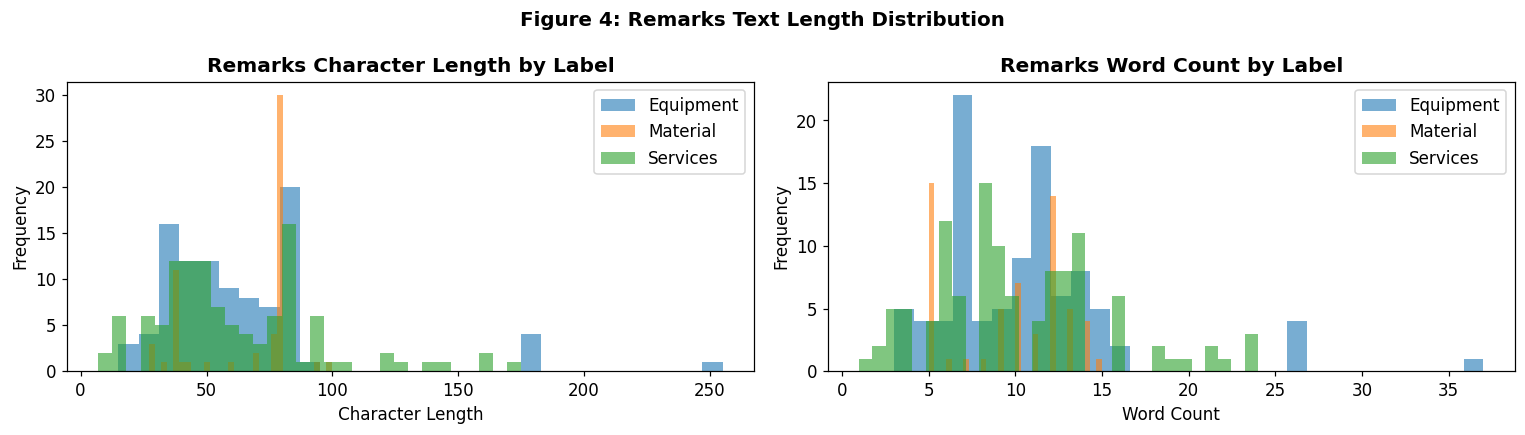

       remark_len  word_count
count       267.0       267.0
mean         62.7        10.2
std          31.8         4.8
min           7.0         1.0
25%          40.0         7.0
50%          58.0        10.0
75%          80.0        13.0
max         255.0        37.0


In [13]:
# Remarks text length
df['remark_len'] = df['Remarks'].str.len()
df['word_count']  = df['Remarks'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, col, title in zip(axes,
        ['remark_len', 'word_count'],
        ['Character Length', 'Word Count']):
    for lbl, grp in df.groupby('Label'):
        ax.hist(grp[col], bins=30, alpha=0.6, label=lbl)
    ax.set_title(f'Remarks {title} by Label', fontweight='bold')
    ax.set_xlabel(title); ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Figure 4: Remarks Text Length Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig4_text_length.png', bbox_inches='tight')
plt.show()

print(df[['remark_len', 'word_count']].describe().round(1))

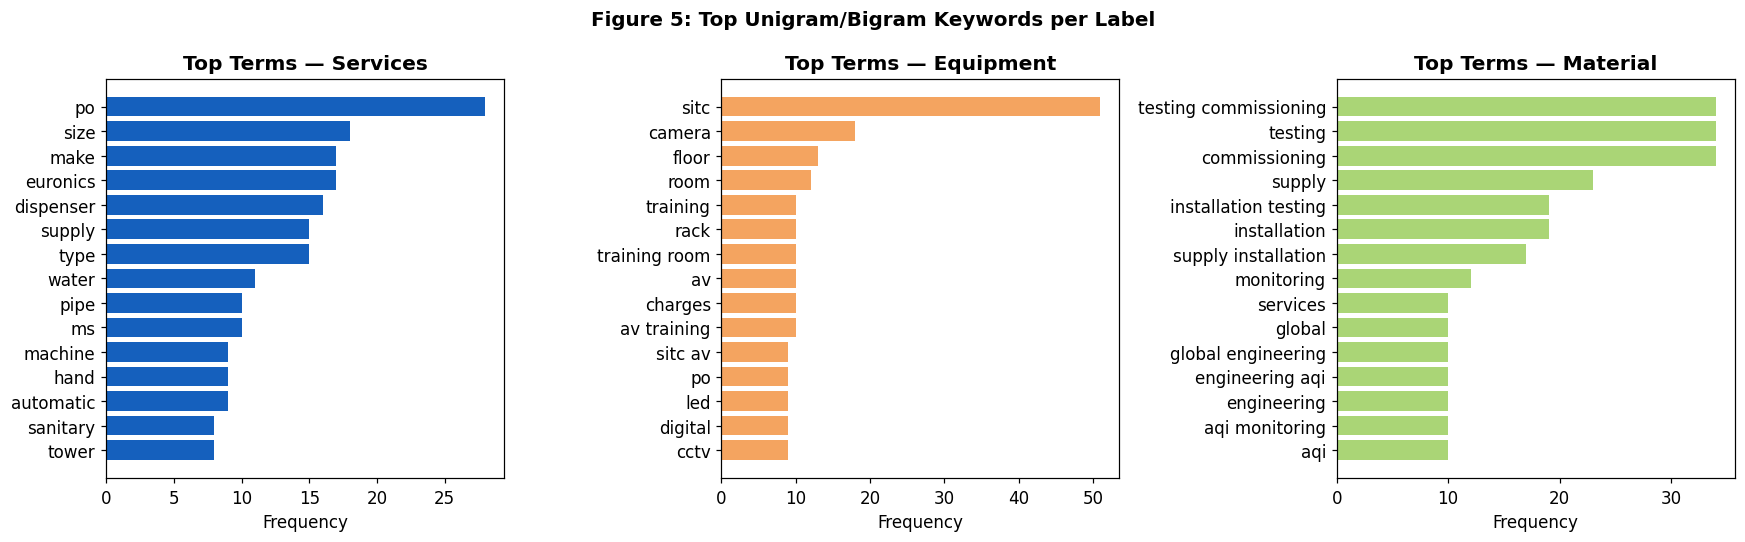

In [14]:
# Top keywords per label
from sklearn.feature_extraction.text import CountVectorizer

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, label in zip(axes, ['Services', 'Equipment', 'Material']):
    subset = df[df['Label'] == label]['Remarks_cleaned']
    vec = CountVectorizer(stop_words='english', max_features=15,
                          ngram_range=(1, 2))
    vec.fit_transform(subset)
    freqs = vec.get_feature_names_out()
    counts = np.asarray(vec.transform(subset).sum(axis=0)).flatten()
    top_idx = np.argsort(counts)[::-1][:15]
    ax.barh([freqs[i] for i in top_idx][::-1],
            [counts[i] for i in top_idx][::-1],
            color={'Services':'#1560BD','Equipment':'#F4A460','Material':'#AAD576'}[label])
    ax.set_title(f'Top Terms — {label}', fontweight='bold')
    ax.set_xlabel('Frequency')

plt.suptitle('Figure 5: Top Unigram/Bigram Keywords per Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('fig5_keywords.png', bbox_inches='tight')
plt.show()


## Feature Engineering & Train/Test Split

In [15]:
# Split data into training and testing sets
X = df['Remarks_cleaned']
y = df['Label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Data split into training and testing sets successfully!")
print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")
print(f"Training label distribution:\n{y_train.value_counts(normalize=True)}")
print(f"Test label distribution:\n{y_test.value_counts(normalize=True)}")

Data split into training and testing sets successfully!
Training set size: 213 samples
Test set size: 54 samples
Training label distribution:
Label
Services     0.422535
Equipment    0.361502
Material     0.215962
Name: proportion, dtype: float64
Test label distribution:
Label
Services     0.425926
Equipment    0.370370
Material     0.203704
Name: proportion, dtype: float64


## Statistical ML Classification

### Choice of Evaluation Metrics

**1. Macro F1-Score**  
Computes F1 per class then takes the unweighted mean. This penalises poor
performance on minority classes equally, which is critical here given class
imbalance (`Material` is the smallest class).

**2. Balanced Accuracy**  
Mean of per-class recall (= macro recall). Robust to imbalance; a random
classifier scores ~0.33 on a 3-class problem. Together with macro F1 it
gives a complete picture of per-class performance.

We evaluate three pipeline variants (TF-IDF + classifier):
- Logistic Regression (L2)
- Linear SVC
- Multinomial Naïve Bayes


In [16]:

label_enc = {'Services': 0, 'Equipment': 1, 'Material': 2}

# Helper
def build_pipeline(clf):
    return Pipeline([
        ('tfidf', TfidfVectorizer(
            ngram_range=(1, 2),
            min_df=1,
            max_features=5000,
            sublinear_tf=True      # log(1+tf) dampens high-frequency terms
        )),
        ('clf', clf)
    ])

classes = np.unique(y_train)
cw = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, cw))
print("Class weights:", class_weight_dict)

Class weights: {'Equipment': np.float64(0.922077922077922), 'Material': np.float64(1.5434782608695652), 'Services': np.float64(0.7888888888888889)}


In [17]:

models = {
    'Logistic Regression': build_pipeline(
        LogisticRegression(
            max_iter=1000, class_weight='balanced', C=1.0, random_state=42
        )
    ),
    'Linear SVC': build_pipeline(
        LinearSVC(max_iter=2000, class_weight='balanced', C=1.0, random_state=42)
    ),
    'Multinomial NB': build_pipeline(
        MultinomialNB(alpha=0.5)
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
print(f"{'Model':<25} {'CV Macro F1':>12} {'CV Bal-Acc':>12}")
print("-" * 52)
for name, pipe in models.items():
    f1_scores  = cross_val_score(pipe, X_train, y_train, cv=cv,
                                  scoring='f1_macro', n_jobs=-1)
    ba_scores  = cross_val_score(pipe, X_train, y_train, cv=cv,
                                  scoring='balanced_accuracy', n_jobs=-1)
    results[name] = {
        'cv_f1_mean':  f1_scores.mean(),
        'cv_f1_std':   f1_scores.std(),
        'cv_ba_mean':  ba_scores.mean(),
        'cv_ba_std':   ba_scores.std(),
    }
    print(f"{name:<25} {f1_scores.mean():.4f} ± {f1_scores.std():.4f}  "
          f"{ba_scores.mean():.4f} ± {ba_scores.std():.4f}")

Model                      CV Macro F1   CV Bal-Acc
----------------------------------------------------
Logistic Regression       0.9144 ± 0.0293  0.9140 ± 0.0271
Linear SVC                0.9259 ± 0.0130  0.9253 ± 0.0146
Multinomial NB            0.9356 ± 0.0180  0.9356 ± 0.0176


In [18]:

# Train best model on full train set, evaluate on test
best_model_name = max(results, key=lambda n: results[n]['cv_f1_mean'])
print(f"Best model (by CV Macro F1): {best_model_name}\n")

best_pipe = models[best_model_name]
best_pipe.fit(X_train, y_train)
y_pred = best_pipe.predict(X_test)

macro_f1  = f1_score(y_test, y_pred, average='macro')
bal_acc   = balanced_accuracy_score(y_test, y_pred)

print(f"Test Macro F1      : {macro_f1:.4f}")
print(f"Test Balanced Acc  : {bal_acc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Equipment','Material','Services']))


Best model (by CV Macro F1): Multinomial NB

Test Macro F1      : 0.8678
Test Balanced Acc  : 0.8775

              precision    recall  f1-score   support

   Equipment       0.77      0.85      0.81        20
    Material       0.92      1.00      0.96        11
    Services       0.90      0.78      0.84        23

    accuracy                           0.85        54
   macro avg       0.86      0.88      0.87        54
weighted avg       0.86      0.85      0.85        54



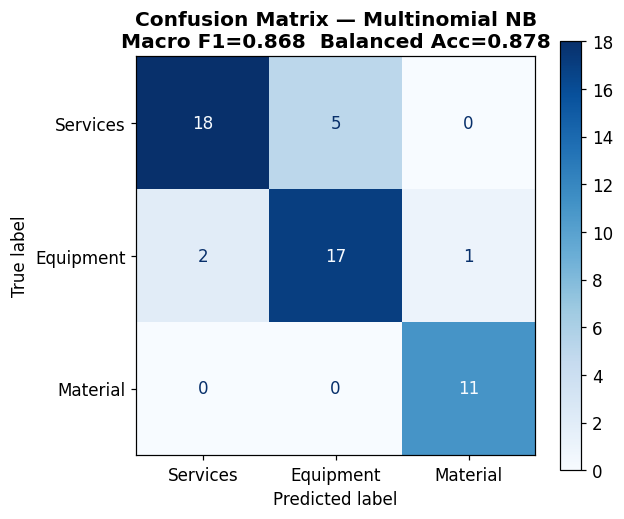

In [19]:
# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred, labels=['Services','Equipment','Material'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Services','Equipment','Material'])
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_model_name}\n'
             f'Macro F1={macro_f1:.3f}  Balanced Acc={bal_acc:.3f}',
             fontweight='bold')
plt.tight_layout()
plt.savefig('fig6_confusion_matrix.png', bbox_inches='tight')
plt.show()

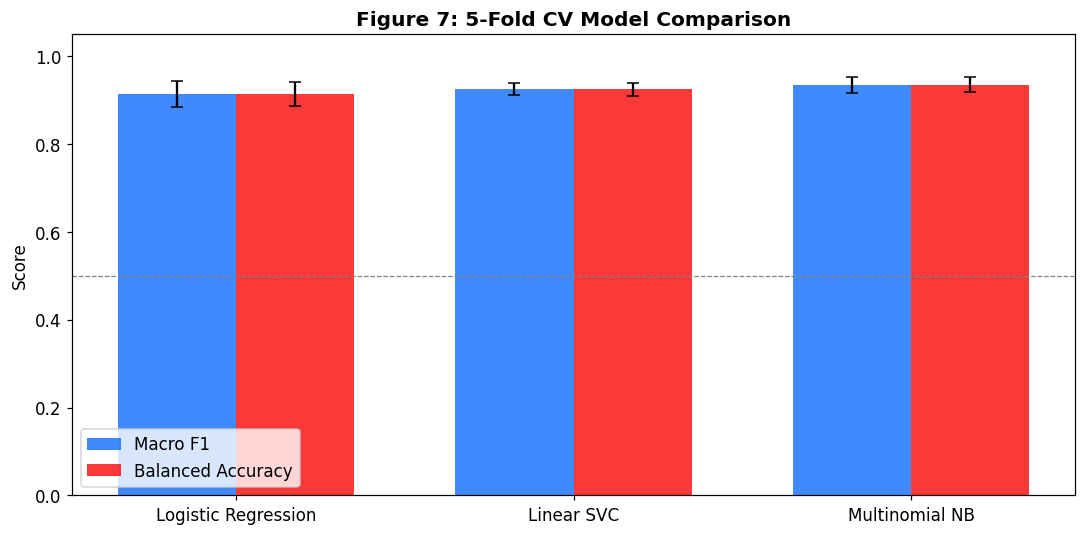

In [20]:
# CV results bar chart
model_names = list(results.keys())
f1_means  = [results[n]['cv_f1_mean']  for n in model_names]
f1_stds   = [results[n]['cv_f1_std']   for n in model_names]
ba_means  = [results[n]['cv_ba_mean']  for n in model_names]
ba_stds   = [results[n]['cv_ba_std']   for n in model_names]

x = np.arange(len(model_names))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
b1 = ax.bar(x - w/2, f1_means,  w, yerr=f1_stds,  label='Macro F1',
            color='#1F75FE', capsize=4, alpha=0.85)
b2 = ax.bar(x + w/2, ba_means,  w, yerr=ba_stds,  label='Balanced Accuracy',
            color='#FB1616', capsize=4, alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score'); ax.set_title('Figure 7: 5-Fold CV Model Comparison',
                                      fontweight='bold')
ax.legend(); ax.axhline(0.5, ls='--', color='grey', lw=0.8, label='Baseline')
plt.tight_layout()
plt.savefig('fig7_model_comparison.png', bbox_inches='tight')
plt.show()

# Alternate option
## Agentic LLM — Zero-Shot Classification

Here want to demonstrate a **Zero-Shot** approach using ***small local model*** from Hugging Face. This avoids API cost, reduces latency, and works offline. For classification, a lightweight instruction model such as *google/flan-t5-small, facebook/bart-large-mnli* works well.
  
Below is a **drop-in replacement** using transformers + **small LLM** ( *valhalla/distilbart-mnli-12-3* ) which is: *~2x faster and ~1-2% less accurate*

The prompt instructs the model to classify each remark into
`Services`, `Equipment`, or `Material` returning structured JSON.

> **Note:** This cell calls the Hugging Face API and requires an API key to be
> available in the environment (`HF_TOKEN`).

HuggingFace small LLM version (local inference)

Why this is better for your use case
* Zero API cost
* Faster for small batches
* No data leaves your environment
* Good enough for 3-class classification
* More accurate for classification
* Less prompt sensitive

Here’s a production-ready version with:
* batch interface (faster) - you can speed up processing by batching
* confidence score (optional threshold)
* safe fallback
* progress logging


In [ ]:
## optional to execute
from dotenv import load_dotenv
import os

load_dotenv()
HF_TOKEN = os.getenv("HF_TOKEN")

In [23]:
import pandas as pd
from transformers import pipeline

print("Raw data use and clean up")
df_llm = df_raw.copy()

# Drop rows where 'Remarks' is NaN before processing
df_llm.dropna(subset=['Remarks'], inplace=True)

# Ensure 'Remarks' column is of string type
df_llm['Remarks'] = df_llm['Remarks'].astype(str)

print("Loading zero-shot classification model...")
# Load once (important for performance)
classifier = pipeline(
    "zero-shot-classification",
    model = "valhalla/distilbart-mnli-12-3"
    #model="facebook/bart-large-mnli"
)

LABELS = ["Services", "Equipment", "Material"]

# Batch llm lable this will avoids calling the model for each row.
def batch_llm_label(remarks):
    results = classifier(
        remarks,
        candidate_labels=LABELS,
        batch_size=16
    )

    labels = []
    for r in results:
        label = r["labels"][0]
        score = r["scores"][0]

        if score < 0.55:
            labels.append("Services")
        else:
            labels.append(label)

    return labels

# Batch Size
batch_size = 32
labels = []

# Batching with progress logging
for i in range(0, len(df), batch_size):
    batch = df_llm["Remarks"].iloc[i:i+batch_size].fillna("").tolist()
    labels.extend(batch_llm_label(batch))
    print(f"Processed {i}/{len(df_llm)}")

df_llm["Label"] = labels

df_llm.to_csv("./content/labelled_data.csv", index=False)

print("Labels saved to labelled_data.csv")

Raw data use and clean up
Loading zero-shot classification model...


Loading weights: 100%|██████████| 283/283 [00:00<00:00, 16307.24it/s]


Processed 0/267
Processed 32/267
Processed 64/267
Processed 96/267
Processed 128/267
Processed 160/267
Processed 192/267
Processed 224/267
Processed 256/267
Labels saved to labelled_data.csv


In [24]:
# Let see what we got in labelled data
try:
    df_llm_csv = pd.read_csv('./content/labelled_data.csv')
    print("'labelled_data.csv' loaded successfully!")
    display(df_llm_csv.head(10))
except FileNotFoundError:
    print("Error: 'labelled_data.csv' not found. Expected LLM lable batch process completed.")
except Exception as e:
    print(f"An error occurred while loading 'labelled_data.csv': {e}")

'labelled_data.csv' loaded successfully!


,Year,Debit,Credit,Net,Remarks,Label
0,FY23,30000.0,0,30000.0,"Services Professional Services , Consultancy A...",Services
1,FY23,270000.0,0,270000.0,"Services Professional Services , Consultancy A...",Services
2,FY23,250000.0,0,250000.0,Exp reclass entry in N2 (Godrej),Services
3,FY23,14500.0,0,14500.0,Dispenser Water - Frosty plus - (Make - Atlantis),Equipment
4,FY23,59400.0,0,59400.0,"Almirah - Office use , Steel Almirah with four...",Equipment
5,FY23,59400.0,0,59400.0,"701257471208 Almirah - Office use , Steel Almi...",Equipment
6,FY23,12400.0,0,12400.0,Dispenser Water - Frosty plus - (Make - Atlantis),Equipment
7,FY23,12735479.0,0,12735479.0,Space matrix Cost T/f from project Upgradation...,Services
8,FY23,315000.0,0,315000.0,Provision reclass of Godrej May22,Services
9,FY23,30200.0,0,30200.0,1.5 Tr. Split AC - 2 Star - Non Inverter ( Dai...,Equipment
